# WISDM Dataset 기반 SENet 분류

## 개요
WISDM 데이터셋에 UCI HAR SENet 구조(Squeeze-and-Excitation Network)를 적용한 분류 모델

- 입력: (200, 3) — 200 timestep, x/y/z 가속도 3채널
- 모델: Conv-SE Block 기반 채널 어텐션 구조


In [1]:
# Library imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, GaussianNoise,
    Multiply, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [4]:
# raw 데이터 로드
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";")
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [5]:
# 클린업
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

df = data.drop('NaN', axis=1)
df = df.dropna()

df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [6]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [7]:
# Data Split (user_id 기반)
df_train = df[df['user_id'] <= 26]
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")


Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [8]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])

In [9]:
# Segmentation (Sliding Window)
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    for i in range(0, len(x) - time_steps, step):
        v = x.iloc[i:i + time_steps].values
        labels = y.iloc[i:i + time_steps]
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [10]:
# 클래스 가중치 (불균형 보정)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## SE Block (Squeeze-and-Excitation Block)
채널별 중요도를 학습해서 중요한 채널은 강조하고, 불필요한 채널은 억제하는 채널 어텐션 구조

### 동작 과정
1. **Squeeze** : GlobalAveragePooling으로 각 채널의 전체 시간 정보를 하나의 값으로 압축
2. **Excitation** : 두 개의 Dense 레이어로 채널 간 관계를 학습해 각 채널의 가중치(0~1)를 계산
   - 첫 번째 Dense: 채널 수를 줄여 핵심 정보만 압축
   - 두 번째 Dense: 원래 채널 수로 복원 후 sigmoid로 0~1 사이 가중치 출력
3. **Scale** : 학습된 가중치를 원래 특징 맵에 곱해 채널별로 재조정

### 사용 목적
CNN이 추출한 특징 중 행동 분류에 더 유용한 센서 채널 패턴을 동적으로 강조하기 위해 사용

### 사용 이유
x/y/z 3개 센서 채널의 중요도가 행동마다 다르기 때문에 SE Block이 매 레이어마다 현재 특징에 맞는 채널 가중치를 학습해 분류 성능을 높임

In [11]:
# SE Block 정의
def se_block(x, ratio=16):
    channels = x.shape[-1]
    reduction = max(channels // ratio, 1)

    # Squeeze: 각 채널의 시간 전체를 평균 → (batch, channels)
    se = GlobalAveragePooling1D()(x)

    # Excitation: 채널 간 관계 학습
    se = Dense(reduction, activation='relu',    use_bias=False)(se)
    se = Dense(channels,  activation='sigmoid', use_bias=False)(se)

    # Scale: (batch, channels) → (batch, 1, channels) 후 원래 특징 맵에 곱함
    se = Reshape((1, channels))(se)
    return Multiply()([x, se])

## Conv-SE Block
두 번의 Conv 연산으로 시간 패턴을 추출한 뒤, SE Block으로 채널 중요도를 재조정

In [12]:
# Conv-SE Block 정의
def conv_se_block(x, filters, kernel_size=3, pool=True, ratio=16):
    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = se_block(x, ratio=ratio)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x

In [13]:
# SENet 모델 정의
def build_senet_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(64, kernel_size=5, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = conv_se_block(x, filters=64,  kernel_size=3, pool=True,  ratio=16)
    x = conv_se_block(x, filters=128, kernel_size=3, pool=True,  ratio=16)
    x = conv_se_block(x, filters=128, kernel_size=3, pool=False, ratio=16)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [14]:
# 모델 생성 및 컴파일
input_shape = (x_train.shape[1], x_train.shape[2])  # (200, 3)
num_classes = 6

model = build_senet_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 200, 3)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │        960 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 200, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 64)   │     12,288 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 200, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 64)   │     12,288 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 200, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 200, 64)   │          0 │ re_lu_2[0][0],    │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 64)   │          0 │ multiply[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 100, 128)  │     24,576 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 100, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 238,662 (932.27 KB)

 Trainable params: 237,254 (926.77 KB)

 Non-trainable params: 1,408 (5.50 KB)

In [15]:
# Callback 설정
callbacks = [
    ModelCheckpoint(
        "WISDM_HAR_SENet_best.keras",
        monitor="val_sparse_categorical_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        mode="max",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

In [16]:
# 모델 학습
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    shuffle=True,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7488 - sparse_categorical_accuracy: 0.7112
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.51976, saving model to WISDM_HAR_SENet_best.keras

Epoch 1: finished saving model to WISDM_HAR_SENet_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - loss: 0.4278 - sparse_categorical_accuracy: 0.8489 - val_loss: 1.5734 - val_sparse_categorical_accuracy: 0.5198 - learning_rate: 3.0000e-04
Epoch 2/100
298/305 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1135 - sparse_categorical_accuracy: 0.9728
Epoch 2: val_sparse_categorical_accuracy improved from 0.51976 to 0.72415, saving model to WISDM_HAR_SENet_best.keras

Epoch 2: finished saving model to WISDM_HAR_SENet_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1043 - sparse_categorical_accuracy: 0.9747 - val_loss: 0.7660 - val_sparse_categorical_accuracy: 0.7241 - learning_rate: 3.0000e-04
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

In [17]:
model = tf.keras.models.load_model("WISDM_HAR_SENet_best.keras")

In [18]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(x_test,  y_test,  verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.53%
Training loss: 0.0140
Test accuracy: 92.36%
Test loss: 0.3305


In [19]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.82      0.91      0.86       346
     Jogging       1.00      0.95      0.97      1316
     Sitting       0.99      1.00      1.00       300
    Standing       1.00      0.99      1.00       189
    Upstairs       0.67      0.84      0.75       384
     Walking       0.95      0.90      0.93      1350

    accuracy                           0.92      3885
   macro avg       0.91      0.93      0.92      3885
weighted avg       0.93      0.92      0.93      3885



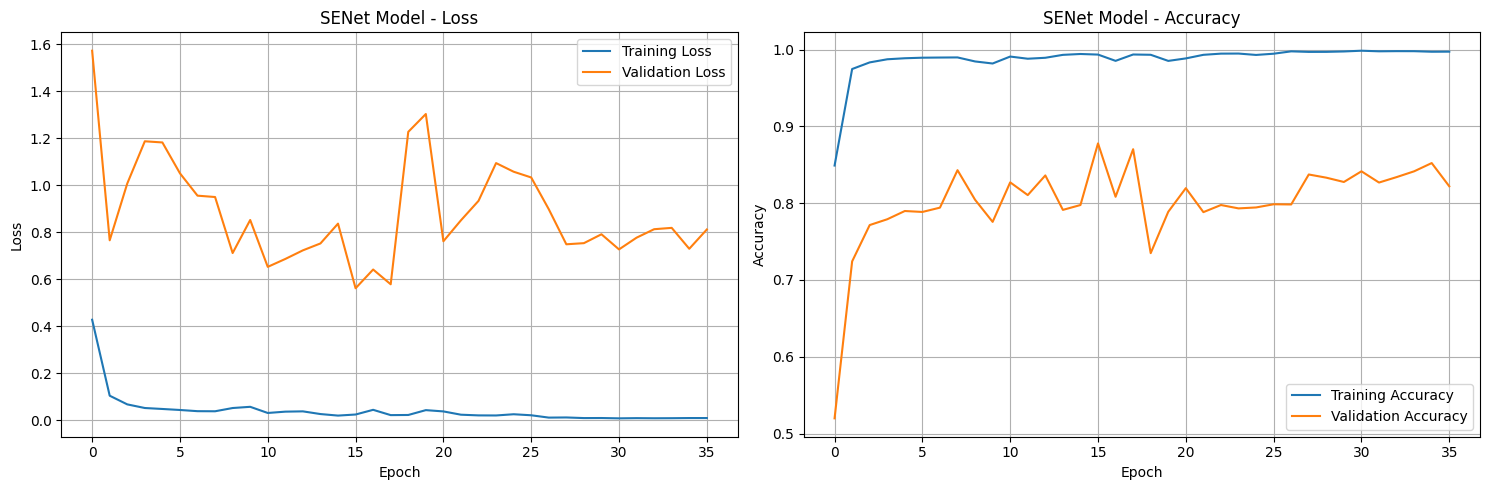

In [20]:
# 학습 곡선 시각화
train_loss_hist = history.history['loss']
val_loss_hist   = history.history['val_loss']
train_acc_hist  = history.history['sparse_categorical_accuracy']
val_acc_hist    = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Training Loss')
plt.plot(val_loss_hist,   label='Validation Loss')
plt.title('SENet Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label='Training Accuracy')
plt.plot(val_acc_hist,   label='Validation Accuracy')
plt.title('SENet Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

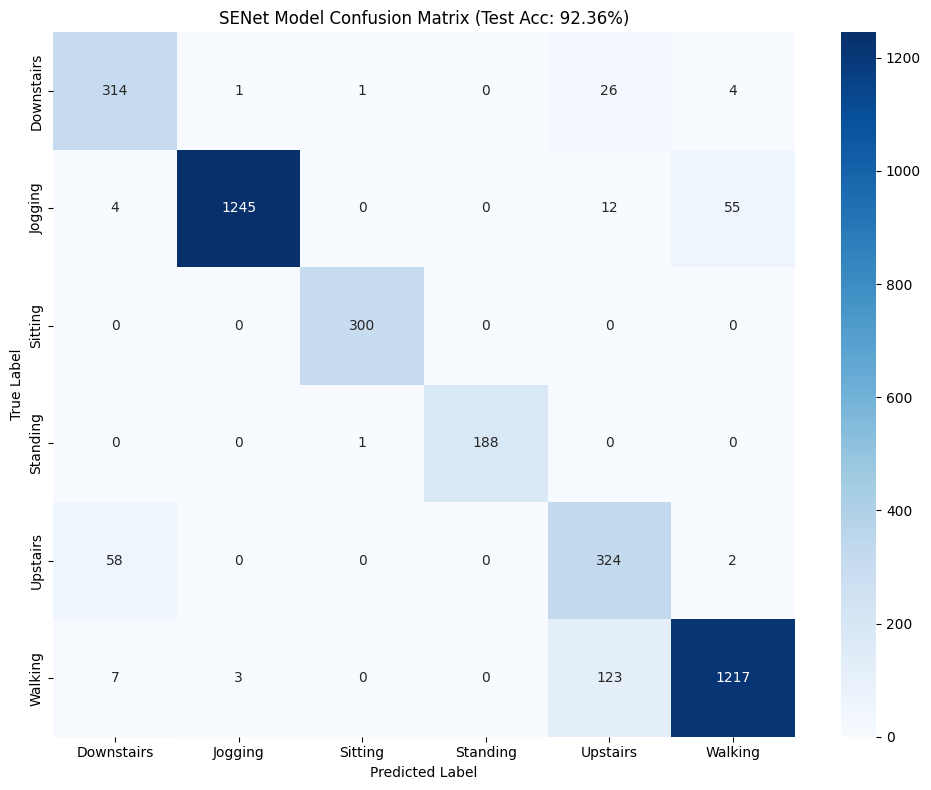

In [21]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'SENet Model Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()